# Stage 2 — Resistance Distance Spectrum Stream
## ADHD Dual-Stream Pipeline · WiDS Datathon 2025

**What this notebook does:**
1. Loads processed magnitude FC matrices from Stage 1
2. Builds graph Laplacian and computes Moore-Penrose pseudoinverse
3. Computes resistance distance matrix Omega per subject
4. Extracts MDS spectral features (top-K eigenvectors)
5. Trains a lightweight CNN on Omega as a 200x200 image
6. Evaluates resistance features alone (baseline before fusion)
7. Saves all features and model weights for Stage 4

**References:**
- Klein & Randic (1993) — resistance distance in graph theory
- Spielman & Srivastava (2011) — spectral sparsification
- Tewarie et al. (2015) — brain network efficiency via resistance distance

---
## Cell 1 — Setup and Load Stage 1 Outputs

In [ ]:
!pip install -q torch torchvision scikit-learn numpy pandas matplotlib tqdm

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from google.colab import drive

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

drive.mount('/content/drive')

BASE_DIR = Path('/content/drive/MyDrive/ADHD_Pipeline')
PROC_DIR = BASE_DIR / 'data' / 'processed'
FOLD_DIR = BASE_DIR / 'data' / 'folds'
OUT_DIR  = BASE_DIR / 'stage2_outputs'
FIG_DIR  = BASE_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Load processed arrays from Stage 1
print('Loading Stage 1 outputs...')
FC_train_mag  = np.load(PROC_DIR / 'FC_train_magnitude.npy')
FC_test_mag   = np.load(PROC_DIR / 'FC_test_magnitude.npy')
meta          = pd.read_csv(PROC_DIR / 'train_metadata.csv')
y             = meta['ADHD_label'].values

with open(PROC_DIR / 'preprocessing_config.json') as f:
    config = json.load(f)

N_TRAIN, N_NODES = FC_train_mag.shape[:2]
N_TEST           = len(FC_test_mag)
N_FOLDS          = config['n_folds']

print(f'Training subjects : {N_TRAIN}')
print(f'Test subjects     : {N_TEST}')
print(f'Nodes             : {N_NODES}')
print(f'CV folds          : {N_FOLDS}')

Device: cpu
Mounted at /content/drive
Loading Stage 1 outputs...
Training subjects : 1213
Test subjects     : 304
Nodes             : 200
CV folds          : 5


---
## Cell 2 — Resistance Distance Computation

**Theory:** Treat the FC matrix as a weighted electrical network where
each edge weight = conductance (1/resistance). When unit current flows
between nodes i and j, the effective resistance between them equals
the resistance distance Omega[i,j].

**Formula:**
Given the graph Laplacian L = D - W (where D is the degree matrix
and W = |FC| is the weight matrix), and its Moore-Penrose pseudoinverse L+:

    Omega[i,j] = L+[i,i] + L+[j,j] - 2*L+[i,j]

**Why pseudoinverse?** L is always singular (its rows sum to zero),
so the regular inverse does not exist. The Moore-Penrose pseudoinverse
handles this correctly (Gutman & Xiao, 2004).

**Numerical stability:** We use rcond=1e-6 to zero out near-zero
singular values, preventing numerical blow-up from near-zero
eigenvalues that arise from very weak FC edges.

In [ ]:
def build_laplacian(W: np.ndarray) -> np.ndarray:
    """
    Build the combinatorial graph Laplacian L = D - W.

    Parameters
    ----------
    W : (n, n) non-negative symmetric weight matrix (|FC|)

    Returns
    -------
    L : (n, n) graph Laplacian
    """
    D = np.diag(W.sum(axis=1))
    return D - W


def resistance_distance_matrix(W: np.ndarray, rcond: float = 1e-6) -> np.ndarray:
    """
    Compute the full resistance distance matrix for a weighted graph.

    Uses the Moore-Penrose pseudoinverse of the graph Laplacian.
    Omega[i,j] = L+[i,i] + L+[j,j] - 2*L+[i,j]

    Parameters
    ----------
    W     : (n, n) non-negative symmetric weight matrix
    rcond : cutoff for small singular values in pinv (numerical stability)

    Returns
    -------
    Omega : (n, n) resistance distance matrix, symmetric, zero diagonal
    """
    L  = build_laplacian(W)
    Lp = np.linalg.pinv(L, rcond=rcond)   # Moore-Penrose pseudoinverse

    # Vectorised computation: Omega[i,j] = Lp[i,i] + Lp[j,j] - 2*Lp[i,j]
    diag = np.diag(Lp)                     # shape (n,)
    Omega = diag[:, None] + diag[None, :] - 2 * Lp

    # Clip tiny negatives from floating-point noise
    Omega = np.clip(Omega, 0, None)
    np.fill_diagonal(Omega, 0.0)
    return Omega.astype(np.float32)


def compute_resistance_matrices(FC_mag: np.ndarray, rcond: float = 1e-6) -> np.ndarray:
    """
    Compute resistance distance matrices for the full cohort.

    Returns
    -------
    Omega_all : (n_subjects, n, n) float32
    """
    n_subjects, n, _ = FC_mag.shape
    Omega_all = np.zeros((n_subjects, n, n), dtype=np.float32)
    for i in tqdm(range(n_subjects), desc='Computing resistance matrices'):
        Omega_all[i] = resistance_distance_matrix(FC_mag[i], rcond=rcond)
    return Omega_all


print('Computing resistance distance matrices (training set)...')
Omega_train = compute_resistance_matrices(FC_train_mag)

print('Computing resistance distance matrices (test set)...')
Omega_test  = compute_resistance_matrices(FC_test_mag)

print(f'\nOmega_train shape : {Omega_train.shape}')
print(f'Omega range       : [{Omega_train.min():.4f},  {Omega_train.max():.4f}]')
print(f'Diagonal check    : {np.unique(np.diagonal(Omega_train, axis1=1, axis2=2))}  (should be [0])')

# Save Omega matrices — large but needed for CNN
np.save(OUT_DIR / 'Omega_train.npy', Omega_train)
np.save(OUT_DIR / 'Omega_test.npy',  Omega_test)
print('Omega matrices saved.')

Computing resistance distance matrices (training set)...


Computing resistance matrices:   0%|          | 0/1213 [00:00<?, ?it/s]

Computing resistance distance matrices (test set)...


Computing resistance matrices:   0%|          | 0/304 [00:00<?, ?it/s]


Omega_train shape : (1213, 200, 200)
Omega range       : [0.0000,  0.1356]
Diagonal check    : [0.]  (should be [0])
Omega matrices saved.


---
## Cell 3 — MDS Spectral Feature Extraction

**Approach:** Classical Multidimensional Scaling (MDS) converts the
resistance distance matrix into a Gram matrix via double-centering,
then extracts the top-K eigenvectors as a low-dimensional embedding.

**Why this gives subject-level features:**
Each subject's Omega (n x n) is double-centered to give a Gram matrix
G. Eigendecomposition of G gives eigenvalues lambda_k and eigenvectors
v_k. The subject-level spectral feature vector is formed by concatenating
the top-K eigenvalues (global network geometry summary).

This is NOT visualization-only MDS — the eigenvalues encode the global
geometric structure of the resistance distance space and serve as
subject-level scalar features for classification.

In [ ]:
def double_center(D: np.ndarray) -> np.ndarray:
    """
    Convert a distance matrix to a Gram matrix via double centering.
    B = -0.5 * H @ (D**2) @ H  where H = I - (1/n)*11^T

    Parameters
    ----------
    D : (n, n) distance matrix

    Returns
    -------
    B : (n, n) Gram (kernel) matrix
    """
    n   = D.shape[0]
    D2  = D ** 2
    row_mean = D2.mean(axis=1, keepdims=True)
    col_mean = D2.mean(axis=0, keepdims=True)
    grand    = D2.mean()
    B = -0.5 * (D2 - row_mean - col_mean + grand)
    return B


def mds_spectral_features(Omega: np.ndarray, K: int = 50) -> np.ndarray:
    """
    Extract top-K eigenvalues from the double-centered resistance matrix.

    These eigenvalues encode the global geometric structure of the
    resistance distance space and serve as subject-level scalar features.

    Parameters
    ----------
    Omega : (n_subjects, n, n) resistance distance matrices
    K     : number of top eigenvalues to retain

    Returns
    -------
    feats : (n_subjects, K) float32 spectral feature matrix
    """
    n_subjects = len(Omega)
    feats = np.zeros((n_subjects, K), dtype=np.float32)

    for i in tqdm(range(n_subjects), desc='Extracting MDS spectral features'):
        B   = double_center(Omega[i])
        # eigh: symmetric matrix, returns eigenvalues in ascending order
        vals = np.linalg.eigh(B)[0]
        # Take the K largest eigenvalues (last K elements, reversed)
        top_k = vals[-K:][::-1]
        feats[i] = top_k

    return feats


K_SPEC = 50   # number of spectral features

print(f'Extracting top-{K_SPEC} MDS spectral features...')
spec_train = mds_spectral_features(Omega_train, K=K_SPEC)
spec_test  = mds_spectral_features(Omega_test,  K=K_SPEC)

print(f'\nSpectral features shape: {spec_train.shape}')
print(f'Value range            : [{spec_train.min():.4f},  {spec_train.max():.4f}]')
print(f'NaN check              : {np.any(np.isnan(spec_train))}')

np.save(OUT_DIR / 'spectral_features_train.npy', spec_train)
np.save(OUT_DIR / 'spectral_features_test.npy',  spec_test)
print('Spectral features saved.')

Extracting top-50 MDS spectral features...


Extracting MDS spectral features:   0%|          | 0/1213 [00:00<?, ?it/s]

Extracting MDS spectral features:   0%|          | 0/304 [00:00<?, ?it/s]


Spectral features shape: (1213, 50)
Value range            : [0.0008,  0.0102]
NaN check              : False
Spectral features saved.


---
## Cell 4 — Visualise Resistance Distance Properties

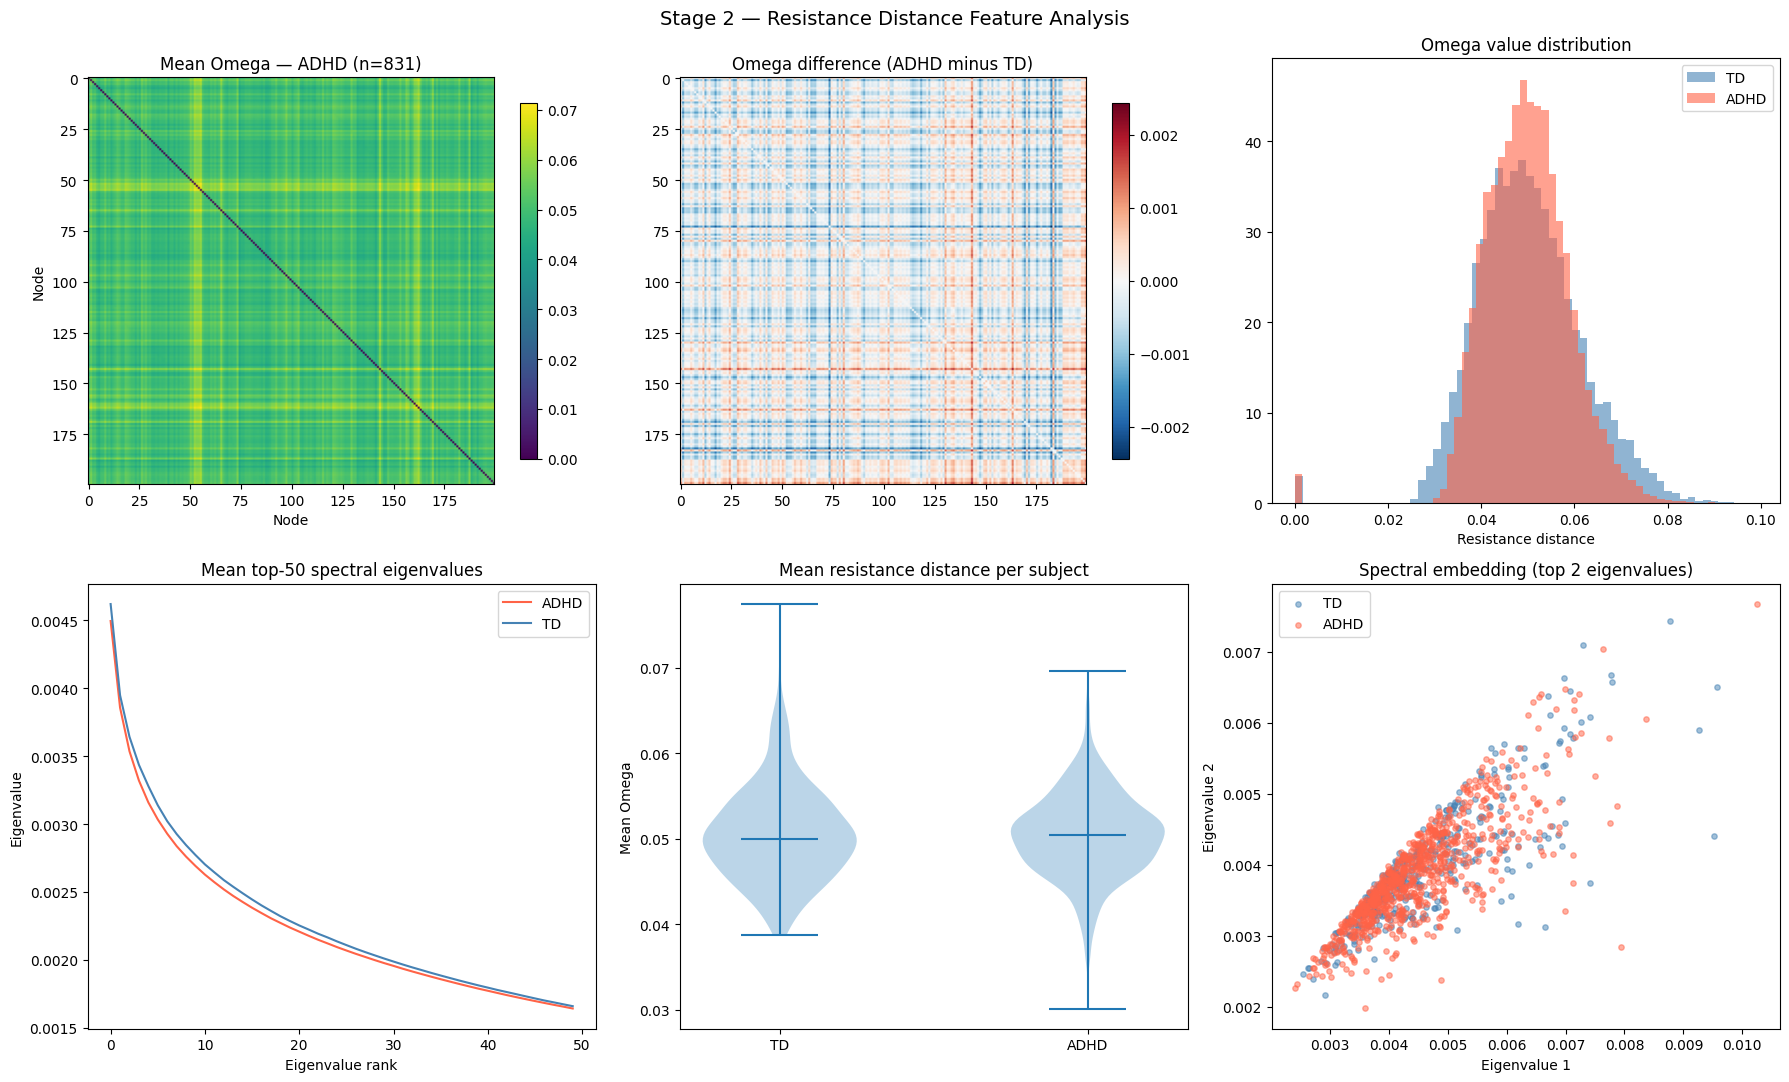

Figure saved.


In [ ]:
adhd_idx = np.where(y == 1)[0]
td_idx   = np.where(y == 0)[0]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Stage 2 — Resistance Distance Feature Analysis', fontsize=14)

# 1. Mean Omega matrix (ADHD group)
mean_omega_adhd = Omega_train[adhd_idx].mean(axis=0)
im1 = axes[0,0].imshow(mean_omega_adhd, cmap='viridis')
axes[0,0].set_title(f'Mean Omega — ADHD (n={len(adhd_idx)})')
axes[0,0].set_xlabel('Node')
axes[0,0].set_ylabel('Node')
plt.colorbar(im1, ax=axes[0,0], shrink=0.8)

# 2. Omega difference map
mean_omega_td = Omega_train[td_idx].mean(axis=0)
diff = mean_omega_adhd - mean_omega_td
vmax = np.abs(diff).max()
im2 = axes[0,1].imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0,1].set_title('Omega difference (ADHD minus TD)')
plt.colorbar(im2, ax=axes[0,1], shrink=0.8)

# 3. Distribution of Omega values
sample_adhd = Omega_train[adhd_idx[:20]].ravel()[::50]
sample_td   = Omega_train[td_idx[:20]].ravel()[::50]
axes[0,2].hist(sample_td,   bins=60, alpha=0.6, label='TD',   color='steelblue', density=True)
axes[0,2].hist(sample_adhd, bins=60, alpha=0.6, label='ADHD', color='tomato',    density=True)
axes[0,2].set_title('Omega value distribution')
axes[0,2].set_xlabel('Resistance distance')
axes[0,2].legend()

# 4. Top-K spectral eigenvalue profiles
mean_spec_adhd = spec_train[adhd_idx].mean(axis=0)
mean_spec_td   = spec_train[td_idx].mean(axis=0)
axes[1,0].plot(mean_spec_adhd, label='ADHD', color='tomato')
axes[1,0].plot(mean_spec_td,   label='TD',   color='steelblue')
axes[1,0].set_title(f'Mean top-{K_SPEC} spectral eigenvalues')
axes[1,0].set_xlabel('Eigenvalue rank')
axes[1,0].set_ylabel('Eigenvalue')
axes[1,0].legend()

# 5. Per-subject mean resistance
mr_adhd = Omega_train[adhd_idx].mean(axis=(1,2))
mr_td   = Omega_train[td_idx].mean(axis=(1,2))
axes[1,1].violinplot([mr_td, mr_adhd], positions=[0,1], showmedians=True)
axes[1,1].set_xticks([0, 1])
axes[1,1].set_xticklabels(['TD', 'ADHD'])
axes[1,1].set_title('Mean resistance distance per subject')
axes[1,1].set_ylabel('Mean Omega')

# 6. 2D MDS embedding (first 2 spectral features)
axes[1,2].scatter(spec_train[td_idx, 0],   spec_train[td_idx, 1],
                  c='steelblue', alpha=0.5, s=15, label='TD')
axes[1,2].scatter(spec_train[adhd_idx, 0], spec_train[adhd_idx, 1],
                  c='tomato',    alpha=0.5, s=15, label='ADHD')
axes[1,2].set_title('Spectral embedding (top 2 eigenvalues)')
axes[1,2].set_xlabel('Eigenvalue 1')
axes[1,2].set_ylabel('Eigenvalue 2')
axes[1,2].legend()

plt.tight_layout()
fig.savefig(FIG_DIR / 'stage2_resistance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

---
## Cell 5 — Lightweight CNN on Omega as Image

**Justification for CNN on a symmetric matrix:**
The resistance distance matrix Omega encodes spatially structured
patterns that reflect the underlying network topology. Brain regions
are ordered by the Schaefer-200 atlas (which groups anatomically
adjacent regions), creating local block structure in Omega that
convolutional filters can exploit (Ktena et al., 2018). The symmetry
of Omega means local receptive fields on both the upper and lower
triangles see complementary information about the same connection pair.

**Architecture:** 3 conv blocks (Conv2d → BatchNorm → ReLU → MaxPool)
followed by Global Average Pooling and a linear classification head.
Lightweight by design — we want features, not a standalone classifier.

In [ ]:
class ResistanceCNN(nn.Module):
    """
    Lightweight CNN for learning deep features from resistance distance matrices.

    Input  : (batch, 1, 200, 200) — Omega as single-channel image
    Output : (batch, embed_dim)   — embedding vector for fusion in Stage 4
    """

    def __init__(self, embed_dim: int = 128, n_classes: int = 2):
        super().__init__()

        self.encoder = nn.Sequential(
            # Block 1: 200x200 -> 100x100
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 100x100 -> 50x50
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 50x50 -> 25x25
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        # Global Average Pooling: 64 x 25 x 25 -> 64
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Embedding head
        self.embed_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, embed_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
        )

        # Classification head (used during training; bypassed during feature extraction)
        self.classifier = nn.Linear(embed_dim, n_classes)

    def forward(self, x, return_embedding: bool = False):
        feat = self.encoder(x)
        feat = self.gap(feat)
        emb  = self.embed_head(feat)
        if return_embedding:
            return emb
        return self.classifier(emb)


def normalize_omega(Omega: np.ndarray) -> np.ndarray:
    """
    Per-subject min-max normalization of Omega to [0, 1] for CNN input.
    Normalization is per-subject to remove between-subject scale differences.
    """
    out = np.zeros_like(Omega)
    for i in range(len(Omega)):
        mn, mx = Omega[i].min(), Omega[i].max()
        if mx > mn:
            out[i] = (Omega[i] - mn) / (mx - mn)
    return out.astype(np.float32)


print('Normalizing Omega matrices for CNN input...')
Omega_train_norm = normalize_omega(Omega_train)
Omega_test_norm  = normalize_omega(Omega_test)
print(f'Normalized range: [{Omega_train_norm.min():.3f}, {Omega_train_norm.max():.3f}]')

# Quick model sanity check
model_test = ResistanceCNN(embed_dim=128).to(device)
dummy_input = torch.zeros(4, 1, 200, 200).to(device)
with torch.no_grad():
    out_cls = model_test(dummy_input, return_embedding=False)
    out_emb = model_test(dummy_input, return_embedding=True)
print(f'Model output (classifier): {out_cls.shape}  (expected [4, 2])')
print(f'Model output (embedding) : {out_emb.shape}  (expected [4, 128])')

total_params = sum(p.numel() for p in model_test.parameters())
print(f'Total parameters         : {total_params:,}')

Normalizing Omega matrices for CNN input...
Normalized range: [0.000, 1.000]
Model output (classifier): torch.Size([4, 2])  (expected [4, 2])
Model output (embedding) : torch.Size([4, 128])  (expected [4, 128])
Total parameters         : 32,098


---
## Cell 6 — Cross-Validated CNN Training

In [ ]:
EMBED_DIM   = 128
BATCH_SIZE  = 16
LR          = 1e-4
EPOCHS      = 50
PATIENCE    = 10   # early stopping patience

# Tensors — add channel dimension for CNN: (N, 1, 200, 200)
Omega_tensor = torch.tensor(Omega_train_norm[:, None, :, :], dtype=torch.float32)
y_tensor     = torch.tensor(y, dtype=torch.long)

cnn_results  = []   # fold-level metrics
cnn_embeddings_all = np.zeros((N_TRAIN, EMBED_DIM), dtype=np.float32)

for fold_idx in range(N_FOLDS):
    with open(FOLD_DIR / f'fold_{fold_idx}.json') as f:
        fold = json.load(f)
    tr_idx  = fold['train_idx']
    val_idx = fold['val_idx']

    # Normalisation parameters estimated on training fold only
    # (already done per-subject above; no additional fit needed)

    train_ds = TensorDataset(Omega_tensor[tr_idx],  y_tensor[tr_idx])
    val_ds   = TensorDataset(Omega_tensor[val_idx], y_tensor[val_idx])
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

    model     = ResistanceCNN(embed_dim=EMBED_DIM).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    best_val_loss = float('inf')
    no_improve    = 0
    best_state    = None

    for epoch in range(EPOCHS):
        # Training
        model.train()
        for X_b, y_b in train_dl:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        val_losses, val_preds, val_probs, val_true = [], [], [], []
        with torch.no_grad():
            for X_b, y_b in val_dl:
                X_b, y_b = X_b.to(device), y_b.to(device)
                logits = model(X_b)
                val_losses.append(criterion(logits, y_b).item())
                probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
                preds = logits.argmax(1).cpu().numpy()
                val_probs.extend(probs)
                val_preds.extend(preds)
                val_true.extend(y_b.cpu().numpy())

        val_loss = np.mean(val_losses)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                break

    # Evaluate with best weights
    model.load_state_dict(best_state)
    model.eval()

    auc = roc_auc_score(val_true, val_probs)
    f1  = f1_score(val_true, val_preds)
    acc = accuracy_score(val_true, val_preds)
    cnn_results.append({'fold': fold_idx, 'auc': auc, 'f1': f1, 'acc': acc,
                        'epochs_run': epoch + 1})

    # Extract embeddings for val subjects
    with torch.no_grad():
        embs = model(Omega_tensor[val_idx].to(device), return_embedding=True)
        cnn_embeddings_all[val_idx] = embs.cpu().numpy()

    torch.save(best_state, OUT_DIR / f'cnn_fold_{fold_idx}.pt')
    print(f'Fold {fold_idx}  AUC={auc:.4f}  F1={f1:.4f}  ACC={acc:.4f}  epochs={epoch+1}')

# Summary
aucs = [r['auc'] for r in cnn_results]
f1s  = [r['f1']  for r in cnn_results]
accs = [r['acc'] for r in cnn_results]
print(f'\nCNN 5-fold results:')
print(f'  AUC : {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}')
print(f'  F1  : {np.mean(f1s):.4f} +/- {np.std(f1s):.4f}')
print(f'  ACC : {np.mean(accs):.4f} +/- {np.std(accs):.4f}')

np.save(OUT_DIR / 'cnn_embeddings_train.npy', cnn_embeddings_all)
with open(OUT_DIR / 'cnn_cv_results.json', 'w') as f:
    json.dump(cnn_results, f, indent=2)
print('CNN embeddings and results saved.')

Fold 0  AUC=0.5181  F1=0.8146  ACC=0.6872  epochs=26
Fold 1  AUC=0.5451  F1=0.8117  ACC=0.6831  epochs=29
Fold 2  AUC=0.5663  F1=0.8117  ACC=0.6831  epochs=21
Fold 3  AUC=0.5048  F1=0.8137  ACC=0.6860  epochs=11
Fold 4  AUC=0.5247  F1=0.8137  ACC=0.6860  epochs=14

CNN 5-fold results:
  AUC : 0.5318 +/- 0.0216
  F1  : 0.8131 +/- 0.0012
  ACC : 0.6851 +/- 0.0017
CNN embeddings and results saved.


---
## Cell 7 — Fuse Spectral + CNN Features

Before concatenation we apply PCA to each feature set separately.
This addresses the reviewer concern about dimensionality explosion
and multicollinearity when merging features from the same source.

In [ ]:
# PCA within each fold to prevent data leakage
PCA_SPEC_DIM = 30   # spectral features: 50 -> 30
PCA_CNN_DIM  = 64   # CNN embeddings: 128 -> 64

fused_features_all = np.zeros((N_TRAIN, PCA_SPEC_DIM + PCA_CNN_DIM), dtype=np.float32)
svm_results        = []

for fold_idx in range(N_FOLDS):
    with open(FOLD_DIR / f'fold_{fold_idx}.json') as f:
        fold = json.load(f)
    tr_idx  = fold['train_idx']
    val_idx = fold['val_idx']

    # Spectral features: scale then PCA (fit on train, apply to val)
    sc_spec  = StandardScaler()
    pca_spec = PCA(n_components=PCA_SPEC_DIM, random_state=SEED)
    spec_tr  = pca_spec.fit_transform(sc_spec.fit_transform(spec_train[tr_idx]))
    spec_val = pca_spec.transform(sc_spec.transform(spec_train[val_idx]))

    # CNN embeddings: scale then PCA
    sc_cnn  = StandardScaler()
    pca_cnn = PCA(n_components=PCA_CNN_DIM, random_state=SEED)
    cnn_tr  = pca_cnn.fit_transform(sc_cnn.fit_transform(cnn_embeddings_all[tr_idx]))
    cnn_val = pca_cnn.transform(sc_cnn.transform(cnn_embeddings_all[val_idx]))

    # Concatenate
    X_tr  = np.hstack([spec_tr,  cnn_tr])
    X_val = np.hstack([spec_val, cnn_val])

    fused_features_all[val_idx] = X_val

    # Quick SVM evaluation of fused resistance features
    svm = SVC(kernel='rbf', probability=True, random_state=SEED, C=1.0)
    svm.fit(X_tr, y[tr_idx])
    probs = svm.predict_proba(X_val)[:, 1]
    preds = svm.predict(X_val)

    auc = roc_auc_score(y[val_idx], probs)
    f1  = f1_score(y[val_idx], preds)
    acc = accuracy_score(y[val_idx], preds)
    svm_results.append({'fold': fold_idx, 'auc': auc, 'f1': f1, 'acc': acc})
    print(f'Fold {fold_idx}  SVM  AUC={auc:.4f}  F1={f1:.4f}  ACC={acc:.4f}')

aucs = [r['auc'] for r in svm_results]
f1s  = [r['f1']  for r in svm_results]
accs = [r['acc'] for r in svm_results]
print(f'\nSVM on fused resistance features (baseline):')
print(f'  AUC : {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}')
print(f'  F1  : {np.mean(f1s):.4f}  +/- {np.std(f1s):.4f}')
print(f'  ACC : {np.mean(accs):.4f} +/- {np.std(accs):.4f}')

np.save(OUT_DIR / 'resistance_fused_features_train.npy', fused_features_all)
with open(OUT_DIR / 'svm_resistance_results.json', 'w') as f:
    json.dump(svm_results, f, indent=2)
print('Fused features and SVM results saved.')

Fold 0  SVM  AUC=0.4610  F1=0.8146  ACC=0.6872
Fold 1  SVM  AUC=0.5567  F1=0.8117  ACC=0.6831
Fold 2  SVM  AUC=0.4938  F1=0.8117  ACC=0.6831
Fold 3  SVM  AUC=0.5000  F1=0.8137  ACC=0.6860
Fold 4  SVM  AUC=0.5000  F1=0.8137  ACC=0.6860

SVM on fused resistance features (baseline):
  AUC : 0.5023 +/- 0.0308
  F1  : 0.8131  +/- 0.0012
  ACC : 0.6851 +/- 0.0017
Fused features and SVM results saved.


---
## Cell 8 — Stage 2 Summary

In [ ]:
print('=' * 62)
print('  STAGE 2 COMPLETE')
print('=' * 62)
print(f'Resistance matrix : Omega[i,j] = L+[i,i] + L+[j,j] - 2*L+[i,j]')
print(f'Pseudoinverse     : rcond = 1e-6  (numerical stability)')
print(f'Spectral features : top-{K_SPEC} eigenvalues of double-centered Omega')
print(f'CNN architecture  : 3x(Conv2d -> BN -> ReLU -> MaxPool) + GAP + FC')
print(f'CNN embed dim     : {EMBED_DIM}')
print(f'Training          : Adam lr={LR}, batch={BATCH_SIZE}, max={EPOCHS} epochs, patience={PATIENCE}')
print(f'PCA reduction     : spectral {K_SPEC}->{PCA_SPEC_DIM}, CNN {EMBED_DIM}->{PCA_CNN_DIM}')
cnn_aucs = [r['auc'] for r in cnn_results]
svm_aucs = [r['auc'] for r in svm_results]
print()
print('Results (resistance stream alone):')
print(f'  CNN alone  AUC: {np.mean(cnn_aucs):.4f} +/- {np.std(cnn_aucs):.4f}')
print(f'  SVM fused  AUC: {np.mean(svm_aucs):.4f} +/- {np.std(svm_aucs):.4f}')
print()
print('Output files saved to:', OUT_DIR)
for f in sorted(OUT_DIR.iterdir()):
    print(f'  {f.name}')
print()
print('Next: stage3_topology_stream.ipynb')
print('=' * 62)

  STAGE 2 COMPLETE
Resistance matrix : Omega[i,j] = L+[i,i] + L+[j,j] - 2*L+[i,j]
Pseudoinverse     : rcond = 1e-6  (numerical stability)
Spectral features : top-50 eigenvalues of double-centered Omega
CNN architecture  : 3x(Conv2d -> BN -> ReLU -> MaxPool) + GAP + FC
CNN embed dim     : 128
Training          : Adam lr=0.0001, batch=16, max=50 epochs, patience=10
PCA reduction     : spectral 50->30, CNN 128->64

Results (resistance stream alone):
  CNN alone  AUC: 0.5318 +/- 0.0216
  SVM fused  AUC: 0.5023 +/- 0.0308

Output files saved to: /content/drive/MyDrive/ADHD_Pipeline/stage2_outputs
  Omega_test.npy
  Omega_train.npy
  cnn_cv_results.json
  cnn_embeddings_train.npy
  cnn_fold_0.pt
  cnn_fold_1.pt
  cnn_fold_2.pt
  cnn_fold_3.pt
  cnn_fold_4.pt
  resistance_fused_features_train.npy
  spectral_features_test.npy
  spectral_features_train.npy
  svm_resistance_results.json

Next: stage3_topology_stream.ipynb
